# Combine All Datasets

> One dataset to rule them all, and in the darkness, bind them.

In [2]:
%load_ext autoreload
%autoreload 2

from helpers import plotLightCurveFromDF, saveLightCurveFromDF, sampleRandomKIC


In [1]:
import lightkurve as lk
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import gc

%matplotlib inline


/Users/wayfinder/Code/fault-in-our-stars/.env/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


---

In [3]:
%%time
K2VARCAT = pd.read_pickle(r"../data/saved-dataframes/K2VARCAT-C-00.pkl")
KCC = pd.read_parquet(r"../data/saved-dataframes/KCC-stitched.parquet")
KEB = pd.read_pickle(r"../data/saved-dataframes/KEB.pkl")


CPU times: user 7.62 s, sys: 6.52 s, total: 14.1 s
Wall time: 11.2 s


---

## Format the K2 Variable Catalog

1. Change classes
2. Drop unnecessary columns
3. Save new parquet set

In [ ]:
K2VARCAT.shape


In [ ]:
K2VARCAT.index.name = "KIC"
K2VARCAT = K2VARCAT.drop(columns=["Campaign"])



In [ ]:
print(K2VARCAT['Class'].value_counts())


In [ ]:
K2VARCAT['Class'].hist()


In [ ]:
K2VARCAT["Class_clean"] = K2VARCAT["Class"].astype(str).str.strip().str.upper()
K2VARCAT["Class_new"] = "Variable Star"

# Apply rules
K2VARCAT.loc[
    K2VARCAT["Class_clean"].isin(["EA", "EB"]),
    "Class_new"
] = "Eclipsing Binary Star"

K2VARCAT.loc[
    K2VARCAT["Class_clean"] == "NOISE",
    "Class_new"
] = "False Positive"

# Replace original column
K2VARCAT = K2VARCAT.drop(columns=["Class"]).rename(columns={"Class_new": "Class"})


In [ ]:
K2VARCAT['Class'].value_counts()


In [ ]:
K2VARCAT['Class'].hist()


In [ ]:
temp = (
    K2VARCAT
    .reset_index()
    [["KIC", "time", "flux", "Class"]]
)


In [ ]:
K2VARCAT = temp.set_index("KIC")


In [ ]:
K2VARCAT


In [ ]:
# K2VARCAT.to_parquet("./local-assets/K2VARCAT_cleaned.parquet")


In [ ]:
%%time
kic = sampleRandomKIC(K2VARCAT)
print(f"--- Plotting Light Curve for KIC {kic} ---")

plotLightCurveFromDF(K2VARCAT, kic)


In [ ]:
# del K2VARCAT
# gc.collect()


---

## Format the Kepler KOI Cumulative Catalog

In [7]:
KCC


,time,flux,flux_err,n_points
KIC,,,,
757450,"[131.51271468758932, 131.5331494016791, 131.55...","[11763.091796875, 11753.1396484375, 11758.1083...","[5.091228008270264, 5.097338676452637, 5.09830...",64795
892772,"[352.39657371611975, 352.43743948176416, 352.4...","[12429.0693359375, 12420.267578125, 12422.0224...","[5.391023635864258, 5.388980865478516, 5.38850...",54967
1025986,"[120.53931629149156, 120.55975094284076, 120.5...","[1312166.625, 1316493.0, 1315990.125, 1315446....","[31.843351364135742, 31.811965942382812, 31.78...",65264
1026032,"[131.5127135392686, 131.53314824846893, 131.55...","[17661.986328125, 17651.8203125, 17646.8378906...","[5.714937686920166, 5.722585201263428, 5.72262...",64795
1026957,"[120.53930025400041, 120.55973490802717, 120.5...","[135977.390625, 135878.828125, 135846.390625, ...","[12.252449035644531, 12.239001274108887, 12.22...",65264
...,...,...,...,...
12833566,"[120.53884536049009, 120.55927955194056, 120.5...","[615853.125, 615784.8125, 615820.875, 615831.1...","[23.11433982849121, 23.04035186767578, 23.0623...",65264
12834874,"[131.51196432943107, 131.53239862471673, 131.5...","[20523.1484375, 20518.134765625, 20502.9824218...","[6.4272379875183105, 6.423366546630859, 6.4251...",64795
12835139,"[120.53879223243712, 120.55922643133817, 120.5...","[51060.73046875, 51034.3828125, 51043.015625, ...","[8.577451705932617, 8.549298286437988, 8.55790...",65264


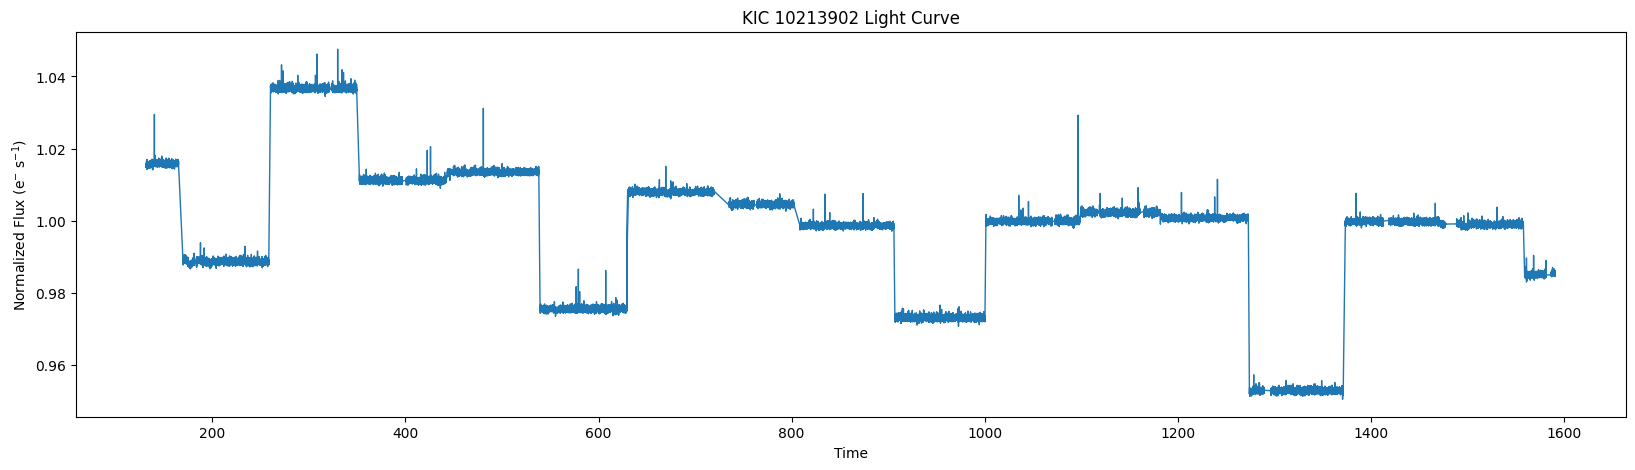

In [13]:
kic = sampleRandomKIC(KCC)
plotLightCurveFromDF(KCC, kic)


In [9]:
KCC = KCC.drop(columns=['n_points', 'flux_err'])


In [10]:
%%time
def normalizeFlux(row):
    flux = np.array(row["flux"])
    median = np.median(flux)
    row["flux"] = flux / median
    
    return row

KCC = KCC.apply(normalizeFlux, axis=1)


CPU times: user 1.62 s, sys: 584 ms, total: 2.21 s
Wall time: 2.22 s


In [4]:
KCC_csv = pd.read_csv("../data/csv-datasets/cumulative_2026.04.10_20.25.58_cleaned.csv")


In [6]:
KCC_csv


,loc_rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,CANDIDATE,CANDIDATE,0.000,0,0,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9559,9560,10090151,K07985.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,1,...,-166.0,4.529,0.035,-0.196,0.903,0.237,-0.079,297.18875,47.093819,14.082
9560,9561,10128825,K07986.01,NaN,CANDIDATE,CANDIDATE,0.497,0,0,0,...,-220.0,4.444,0.056,-0.224,1.031,0.341,-0.114,286.50937,47.163219,14.757
9561,9562,10147276,K07987.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.021,0,0,1,...,-236.0,4.447,0.056,-0.224,1.041,0.341,-0.114,294.16489,47.176281,15.385
9562,9563,10155286,K07988.01,NaN,CANDIDATE,CANDIDATE,0.092,0,0,0,...,-128.0,2.992,0.030,-0.027,7.824,0.223,-1.896,296.76288,47.145142,10.998


In [ ]:
KCC


,time,flux
KIC,,
757450,"[131.51271468758932, 131.5331494016791, 131.55...","[1.0392150925008297, 1.0383358659303283, 1.038..."
892772,"[352.39657371611975, 352.43743948176416, 352.4...","[1.019566672226177, 1.0188446568700726, 1.0189..."
1025986,"[120.53931629149156, 120.55975094284076, 120.5...","[1.0488531548750866, 1.0523113529281902, 1.051..."
1026032,"[131.5127135392686, 131.53314824846893, 131.55...","[1.0509398498643578, 1.0503349421979056, 1.050..."
1026957,"[120.53930025400041, 120.55973490802717, 120.5...","[1.0599377280481261, 1.0591694377327983, 1.058..."
...,...,...
12833566,"[120.53884536049009, 120.55927955194056, 120.5...","[1.0261310309859049, 1.0260172090806345, 1.026..."
12834874,"[131.51196432943107, 131.53239862471673, 131.5...","[1.0000221743860336, 0.9997778754635089, 0.999..."
12835139,"[120.53879223243712, 120.55922643133817, 120.5...","[1.0240593743126658, 1.0235309532711672, 1.023..."


In [25]:
def collapse_disposition(group):
    if (group == "CONFIRMED").any():
        return "CONFIRMED"
    elif (group == "CANDIDATE").any():
        return "CANDIDATE"
    else:
        return "FALSE POSITIVE"

koi_map = (
    KCC_csv
    .groupby("kepid")["koi_disposition"]
    .apply(collapse_disposition)
)


In [26]:
KCC = KCC.join(koi_map)


In [27]:
KCC


,time,flux,koi_disposition
KIC,,,
757450,"[131.51271468758932, 131.5331494016791, 131.55...","[1.0392150925008297, 1.0383358659303283, 1.038...",CONFIRMED
892772,"[352.39657371611975, 352.43743948176416, 352.4...","[1.019566672226177, 1.0188446568700726, 1.0189...",FALSE POSITIVE
1025986,"[120.53931629149156, 120.55975094284076, 120.5...","[1.0488531548750866, 1.0523113529281902, 1.051...",CANDIDATE
1026032,"[131.5127135392686, 131.53314824846893, 131.55...","[1.0509398498643578, 1.0503349421979056, 1.050...",FALSE POSITIVE
1026957,"[120.53930025400041, 120.55973490802717, 120.5...","[1.0599377280481261, 1.0591694377327983, 1.058...",CONFIRMED
...,...,...,...
12833566,"[120.53884536049009, 120.55927955194056, 120.5...","[1.0261310309859049, 1.0260172090806345, 1.026...",FALSE POSITIVE
12834874,"[131.51196432943107, 131.53239862471673, 131.5...","[1.0000221743860336, 0.9997778754635089, 0.999...",CONFIRMED
12835139,"[120.53879223243712, 120.55922643133817, 120.5...","[1.0240593743126658, 1.0235309532711672, 1.023...",FALSE POSITIVE


In [28]:
KCC['koi_disposition'].value_counts()


koi_disposition
FALSE POSITIVE    4603
CONFIRMED         1973
CANDIDATE         1638
Name: count, dtype: int64

In [30]:
KCC = KCC.rename(columns={
    'koi_disposition': 'Class'
})
KCC


,time,flux,Class
KIC,,,
757450,"[131.51271468758932, 131.5331494016791, 131.55...","[1.0392150925008297, 1.0383358659303283, 1.038...",CONFIRMED
892772,"[352.39657371611975, 352.43743948176416, 352.4...","[1.019566672226177, 1.0188446568700726, 1.0189...",FALSE POSITIVE
1025986,"[120.53931629149156, 120.55975094284076, 120.5...","[1.0488531548750866, 1.0523113529281902, 1.051...",CANDIDATE
1026032,"[131.5127135392686, 131.53314824846893, 131.55...","[1.0509398498643578, 1.0503349421979056, 1.050...",FALSE POSITIVE
1026957,"[120.53930025400041, 120.55973490802717, 120.5...","[1.0599377280481261, 1.0591694377327983, 1.058...",CONFIRMED
...,...,...,...
12833566,"[120.53884536049009, 120.55927955194056, 120.5...","[1.0261310309859049, 1.0260172090806345, 1.026...",FALSE POSITIVE
12834874,"[131.51196432943107, 131.53239862471673, 131.5...","[1.0000221743860336, 0.9997778754635089, 0.999...",CONFIRMED
12835139,"[120.53879223243712, 120.55922643133817, 120.5...","[1.0240593743126658, 1.0235309532711672, 1.023...",FALSE POSITIVE


In [31]:
KCC.to_parquet("./local-assets/KCC_cleaned.parquet")


---

In [ ]:
KEB


,index,period,period_err,bjd0,bjd0_err,morph,GLon,GLat,kmag,Teff,SC,time,flux,flux_err,n_points
KIC,,,,,,,,,,,,,,,
3863594,0,0.053268,0.0,55000.000000,0.004327,0.79,-1.0000,-1.0000,-1.000,-1.0,False,"[120.53895485026442, 120.55938947320828, 120.5...","[1.0027486085891724, 0.9967120885848999, 0.999...","[9.64640494203195e-05, 9.793051140150055e-05, ...",52286
10417986,1,0.073731,0.0,55000.027476,0.004231,0.99,81.0390,11.0820,9.128,-1.0,True,"[120.53855550513981, 120.55898988617264, 120.5...","[0.999791145324707, 0.9999734163284302, 0.9995...","[1.373476243315963e-05, 1.3659494470630307e-05...",52200
8912468,2,0.094838,0.0,54953.576945,0.005326,0.98,80.1095,7.8882,11.751,6194.0,False,"[120.53837293142715, 120.55880740127031, 120.5...","[0.9991673827171326, 0.9996739625930786, 0.995...","[5.4617426940239966e-05, 5.44519534741994e-05,...",65266
8758716,3,0.107205,0.0,54953.672989,0.006197,1.00,77.7478,11.6565,13.531,-1.0,False,"[120.53883156277152, 120.55926600434032, 120.5...","[1.0111474990844727, 0.9915452003479004, 1.001...","[0.00011227018694626167, 0.0001110159646486863...",65262
10855535,4,0.112782,0.0,54964.629315,0.006374,0.99,79.3949,15.9212,13.870,7555.0,False,"[131.51221361904754, 131.5326480107833, 131.55...","[0.9962518215179443, 1.0047160387039185, 1.005...","[0.00015937240095809102, 0.0001598708040546625...",64793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9408440,2915,989.985000,-1.0,55346.365980,0.096130,0.00,78.5607,12.2615,13.199,5688.0,False,"[120.53881482224824, 120.55924923285056, 120.5...","[1.0003937482833862, 1.0000361204147339, 1.000...","[0.00010846254008356482, 0.0001084753821487538...",65266
8054233,2916,1058.000000,-1.0,54751.806288,0.968052,0.03,78.6142,7.7321,11.783,4733.0,False,"[120.53847295136802, 120.55890745798388, 120.5...","[0.9990968108177185, 0.9993742108345032, 0.999...","[5.2870946092298254e-05, 5.34793252882082e-05,...",56339
7672940,2917,1064.270000,-1.0,54977.092960,0.089646,0.00,74.5296,14.6136,12.328,-1.0,False,"[120.53926443521777, 120.55969887806714, 120.5...","[0.9998093247413635, 0.9997530579566956, 0.999...","[5.69680159969721e-05, 5.723865979234688e-05, ...",65261


In [33]:
KEB = KEB[["time", "flux"]]
KEB['Class'] = 'Eclipsing Binary Star'


In [ ]:
KEB


,time,flux,Class
KIC,,,
3863594,"[120.53895485026442, 120.55938947320828, 120.5...","[1.0027486085891724, 0.9967120885848999, 0.999...",Eclipsing Binary Star
10417986,"[120.53855550513981, 120.55898988617264, 120.5...","[0.999791145324707, 0.9999734163284302, 0.9995...",Eclipsing Binary Star
8912468,"[120.53837293142715, 120.55880740127031, 120.5...","[0.9991673827171326, 0.9996739625930786, 0.995...",Eclipsing Binary Star
8758716,"[120.53883156277152, 120.55926600434032, 120.5...","[1.0111474990844727, 0.9915452003479004, 1.001...",Eclipsing Binary Star
10855535,"[131.51221361904754, 131.5326480107833, 131.55...","[0.9962518215179443, 1.0047160387039185, 1.005...",Eclipsing Binary Star
...,...,...,...
9408440,"[120.53881482224824, 120.55924923285056, 120.5...","[1.0003937482833862, 1.0000361204147339, 1.000...",Eclipsing Binary Star
8054233,"[120.53847295136802, 120.55890745798388, 120.5...","[0.9990968108177185, 0.9993742108345032, 0.999...",Eclipsing Binary Star
7672940,"[120.53926443521777, 120.55969887806714, 120.5...","[0.9998093247413635, 0.9997530579566956, 0.999...",Eclipsing Binary Star


In [35]:
KEB.to_parquet("./local-assets/KEB_cleaned.parquet")


---

In [36]:
del KCC, KCC_csv, KEB, K2VARCAT, 
gc.collect()


17349

---

## Concatenate the Cleaned DataFrames

In [38]:
%%time
KCC = pd.read_parquet("local-assets/KCC_cleaned.parquet")
KEB = pd.read_parquet("local-assets/KEB_cleaned.parquet")
K2 = pd.read_parquet("local-assets/K2VARCAT_cleaned.parquet")


CPU times: user 4.42 s, sys: 4.48 s, total: 8.9 s
Wall time: 6.29 s
